## Exploratory data analysis

- missingness audit with heatmaps
- z_score sanity check with histograms
- demographic breakdown with bar charts/count plots
- severity distributions with stacked bar charts
- academic performance vs. mental health (boxplots/violin plots)
- timeline of burnout (line plots/boxplots)
- inter-condition correlations (correlation matrix heatmap)
- source comparison (overlapping density plots/violin plots)
- departmental pressure (horizontal boxplots)

In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# assume notebook is run from project root
ROOT = Path.cwd()
DATA = ROOT / "data"
PLOTS = ROOT / "plots"

In [119]:
mhp_dataset = pd.read_parquet(DATA / "mhp_dataset.parquet")

### missingness audit

Columns with missing values:


,n_missing,pct_missing
anxiety_level,8,0.34
anxiety_z_score,8,0.34


Sentinel categories summary


,column,level,n,pct
0,department,not_recorded,351,14.754098
1,cgpa,other,181,7.608239
2,academic_year,other,147,6.179067
3,department,other,79,3.320723
4,gender,other,10,0.420345
5,academic_year,unknown,5,0.210172


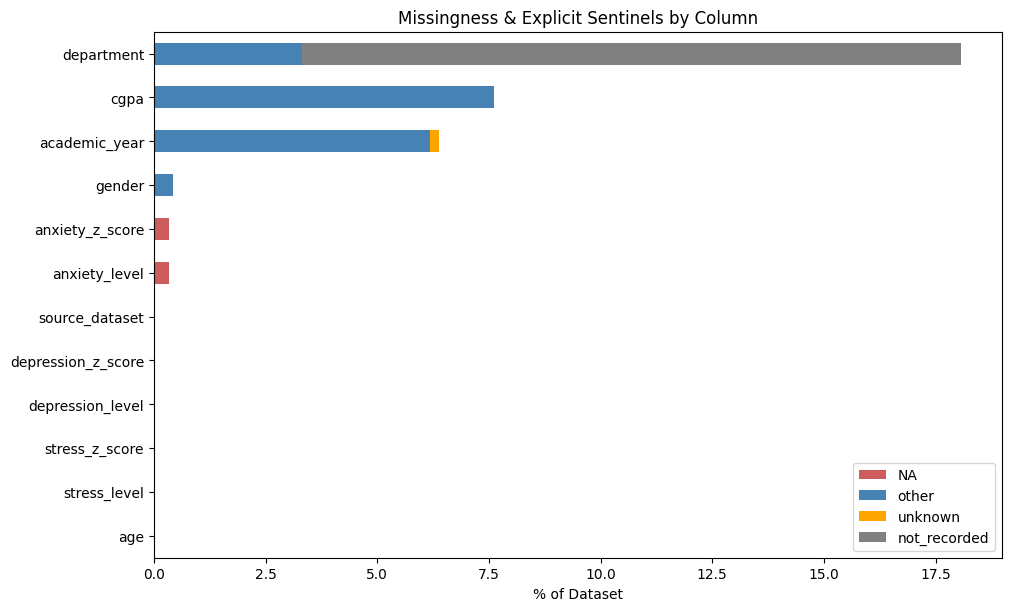

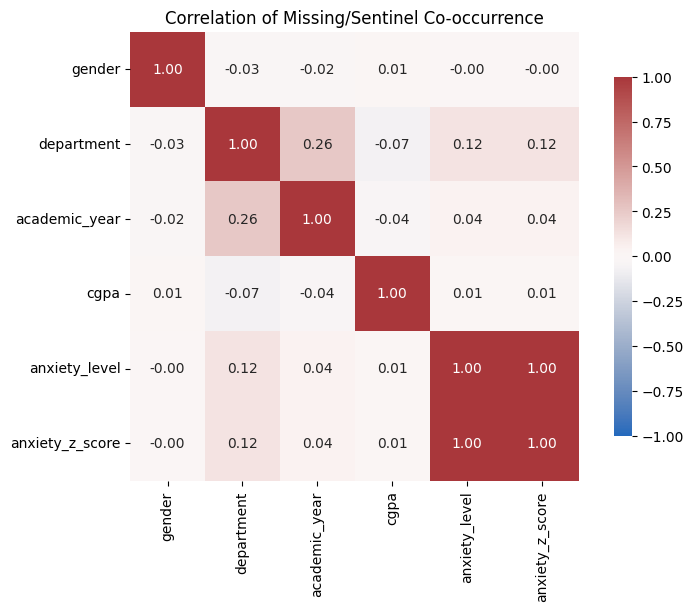

In [120]:
n = len(mhp_dataset)

PLACEHOLDER_LABELS = ["other", "unknown", "not_recorded"]

na_counts = mhp_dataset.isna().sum()
na_pct = (na_counts / n) * 100

if na_counts.sum() > 0:
    print("Columns with missing values:")
    na_df = pd.DataFrame(
        {"n_missing": na_counts, "pct_missing": (na_counts / n * 100).round(2)}
    )
    display(na_df[na_df["n_missing"] > 0].sort_values("n_missing"))

sentinel_rows = []
for col in mhp_dataset.columns:
    for label in PLACEHOLDER_LABELS:
        count = mhp_dataset[col].isin([label]).sum()
        if count > 0:
            sentinel_rows.append(
                {"column": col, "level": label, "n": count, "pct": (count / n) * 100}
            )

if sentinel_rows:
    print("Sentinel categories summary")
    sentinel_tbl = pd.DataFrame(sentinel_rows).sort_values(
        ["pct", "level"], ascending=False, ignore_index=True
    )
    display(sentinel_tbl)


stack_components = pd.DataFrame(index=mhp_dataset.columns)
stack_components["NA"] = na_pct
for label in PLACEHOLDER_LABELS:
    stack_components[label] = (mhp_dataset.isin([label]).sum() / n) * 100

cols_order = stack_components.sum(axis=1).sort_values(ascending=True).index
stack_plot = stack_components.loc[cols_order]

color_map = {
    "NA": "indianred",
    "other": "steelblue",
    "unknown": "orange",
    "not_recorded": "gray",
}

fig0, ax0 = plt.subplots(figsize=(10, 6), constrained_layout=True)

stack_plot.plot(kind="barh", stacked=True, color=color_map, ax=ax0)

ax0.set_xlabel("% of Dataset")
ax0.set_title("Missingness & Explicit Sentinels by Column")
ax0.legend(loc="lower right")


fig1, ax1 = plt.subplots(figsize=(8, 6), constrained_layout=True)
combined_mask = mhp_dataset.isna() | mhp_dataset.isin(PLACEHOLDER_LABELS)
varied_cols = [col for col in combined_mask.columns if combined_mask[col].var() > 0]

correlation_matrix = combined_mask[varied_cols].corr()
sns.heatmap(
    correlation_matrix,
    ax=ax1,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
)
ax1.set_title("Correlation of Missing/Sentinel Co-occurrence")


plt.show()

In [121]:
fig0.savefig(PLOTS / "missingness_audit.svg", format="svg", bbox_inches="tight")
fig1.savefig(PLOTS / "missingness_correlation.svg", format="svg", bbox_inches="tight")

### z score sanity check

Z-score summary (expect mean ~0 and std ~1):


,count,mean,std,min,max
stress_z_score,2379.0,-0.0,0.9998,-3.4046,3.1975
anxiety_z_score,2371.0,0.0,0.9998,-2.2472,3.0609
depression_z_score,2379.0,-0.0,0.9998,-2.1637,3.1952


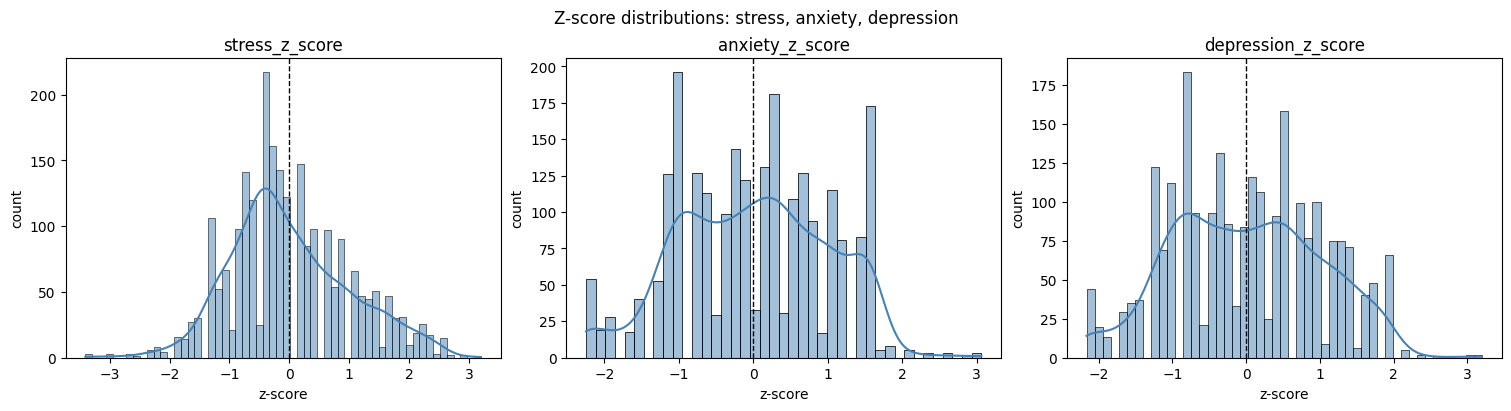

In [122]:
Z_SCORE_COLS = ["stress_z_score", "anxiety_z_score", "depression_z_score"]

z_summary = (
    mhp_dataset[Z_SCORE_COLS].agg(["count", "mean", "std", "min", "max"]).round(4).T
)
print("Z-score summary (expect mean ~0 and std ~1):")
display(z_summary)

fig2, axes = plt.subplots(
    1, len(Z_SCORE_COLS), figsize=(15, 4), constrained_layout=True
)

for ax, col in zip(axes, Z_SCORE_COLS):
    unique_vals = mhp_dataset[col].nunique()
    sns.histplot(
        mhp_dataset[col].dropna(), bins=unique_vals, kde=True, ax=ax, color="steelblue"
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("z-score")
    ax.set_ylabel("count")

fig2.suptitle("Z-score distributions: stress, anxiety, depression")
plt.show()

In [123]:
fig2.savefig(PLOTS / "z_score_distributions.svg", format="svg", bbox_inches="tight")

### demographic breakdown


Demographic frequency tables:


,age,count,pct
0,18-22,1514,63.64
1,23-26,830,34.89
2,27-30,28,1.18
3,<18,4,0.17
4,>30,3,0.13


,gender,count,pct
0,male,1616,67.93
1,female,753,31.65
2,other,10,0.42


,academic_year,count,pct
0,third,684,28.75
1,first,654,27.49
2,fourth,459,19.29
3,second,430,18.07
4,other,147,6.18
5,unknown,5,0.21


,cgpa,count,pct
0,3.00-3.39,696,29.26
1,3.40-3.79,664,27.91
2,2.50-2.99,460,19.34
3,3.80-4.00,283,11.90
4,other,181,7.61
5,<2.50,95,3.99


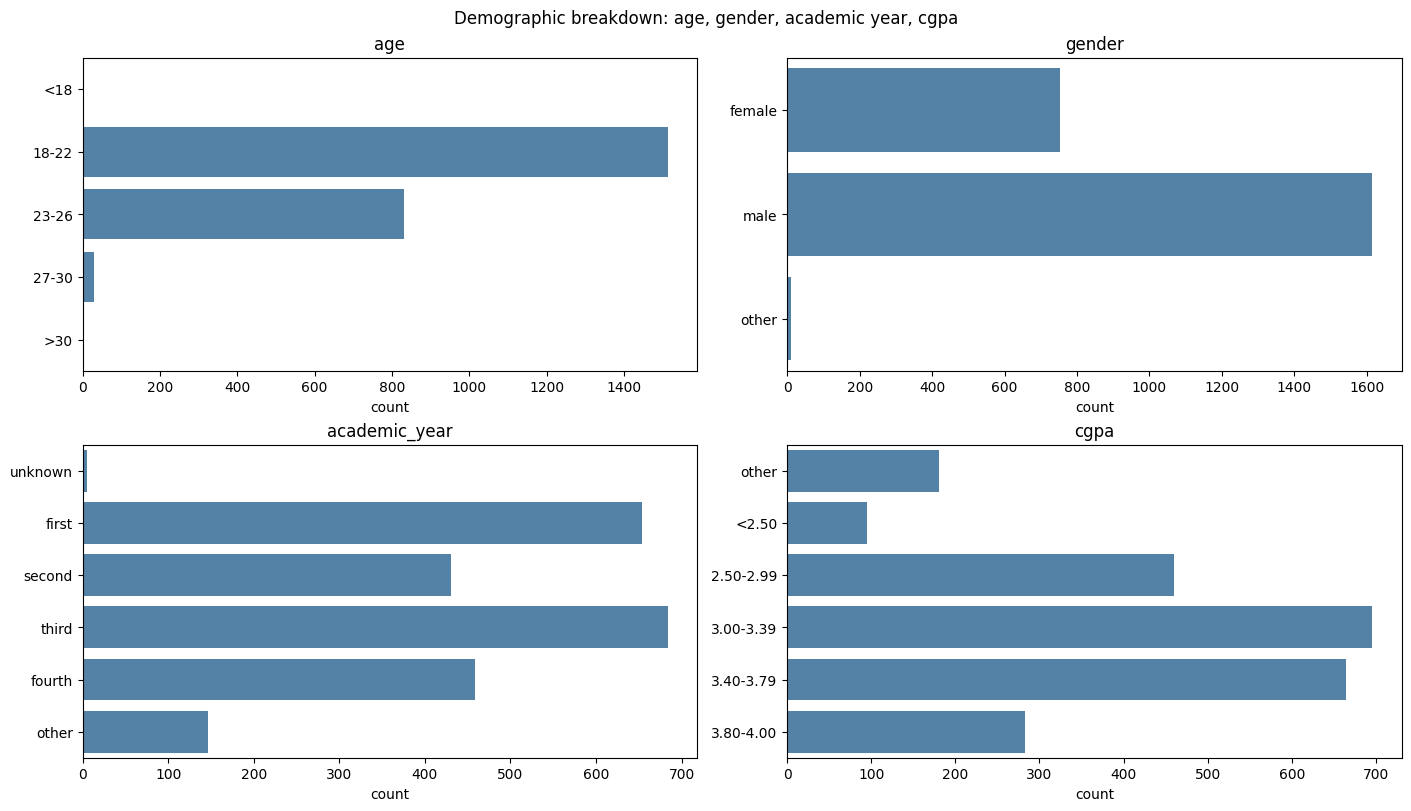

In [124]:
DEMOGRAPHIC_COLS = ["age", "gender", "academic_year", "cgpa"]

print("Demographic frequency tables:")
for col in DEMOGRAPHIC_COLS:
    freq = mhp_dataset[col].value_counts().rename_axis(col).reset_index(name="count")
    freq["pct"] = ((freq["count"] / len(mhp_dataset)) * 100).round(2)
    display(freq)

fig3, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
axes = axes.flatten()

for ax, col in zip(axes, DEMOGRAPHIC_COLS):
    is_categorical = isinstance(mhp_dataset[col].dtype, pd.CategoricalDtype)
    plot_order = None if is_categorical else mhp_dataset[col].value_counts().index

    sns.countplot(data=mhp_dataset, y=col, order=plot_order, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("count")
    ax.set_ylabel("")

fig3.suptitle("Demographic breakdown: age, gender, academic year, cgpa")
plt.show()

In [125]:
fig3.savefig(PLOTS / "demographic_breakdown.svg", format="svg", bbox_inches="tight")

### severity distributions with stacked bar charts

Severity distribution by condition (%):


,none,minimal,mild,moderate,moderately_severe,severe
stress,2.56,12.99,1.77,57.92,0.80,23.96
anxiety,2.66,9.91,22.48,30.03,1.48,33.45
depression,4.71,7.94,19.71,22.57,22.57,22.49


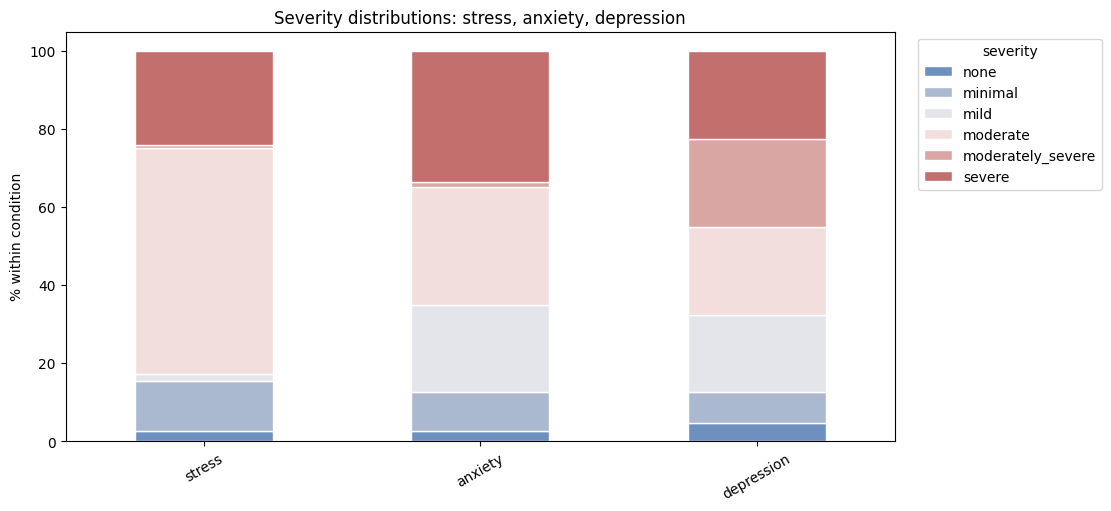

In [126]:
SEVERITY_COLS = ["depression_level", "anxiety_level", "stress_level"]
SEVERITY_ORDER = ["none", "minimal", "mild", "moderate", "moderately_severe", "severe"]
CONDITION_ORDER = ["stress", "anxiety", "depression"]

sef_df = mhp_dataset[SEVERITY_COLS].rename(columns=lambda x: x.replace("_level", ""))

plot_tbl = (sef_df.apply(lambda x: x.value_counts(normalize=True)).T * 100).reindex(
    index=CONDITION_ORDER, columns=SEVERITY_ORDER
)

print("Severity distribution by condition (%):")
display(plot_tbl.round(2))

fig4, ax4 = plt.subplots(figsize=(11, 5), constrained_layout=True)
plot_tbl.plot(
    kind="bar",
    stacked=True,
    ax=ax4,
    color=sns.color_palette("vlag", len(SEVERITY_ORDER)),
    edgecolor="white",
)

ax4.set_title("Severity distributions: stress, anxiety, depression")
ax4.set_xlabel("")
ax4.set_ylabel("% within condition")
ax4.tick_params(axis="x", rotation=30)
ax4.legend(title="severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [127]:
fig4.savefig(PLOTS / "severity_distributions.svg", format="svg", bbox_inches="tight")

### academic performance vs. mental health

Mental-health z-score summary by CGPA band:


stress_z_score               anxiety_z_score                \
                   count   mean median           count   mean median   
cgpa                                                                   
other                181  0.142    0.0             180 -0.024 -0.063   
<2.50                 95  0.092 -0.148              95  0.015  0.119   
2.50-2.99            460  0.072 -0.148             459  0.103  0.119   
3.00-3.39            696 -0.049 -0.148             693 -0.064 -0.063   
3.40-3.79            664 -0.005 -0.148             661  0.018 -0.019   
3.80-4.00            283 -0.107 -0.296             283 -0.041 -0.063   

          depression_z_score                
                       count   mean median  
cgpa                                        
other                    181 -0.025 -0.064  
<2.50                     95 -0.016  0.086  
2.50-2.99                460  0.105  0.086  
3.00-3.39                696 -0.044 -0.064  
3.40-3.79                664  0.013 -0.064  
3.80-4.00                283 -0.072 -0.064

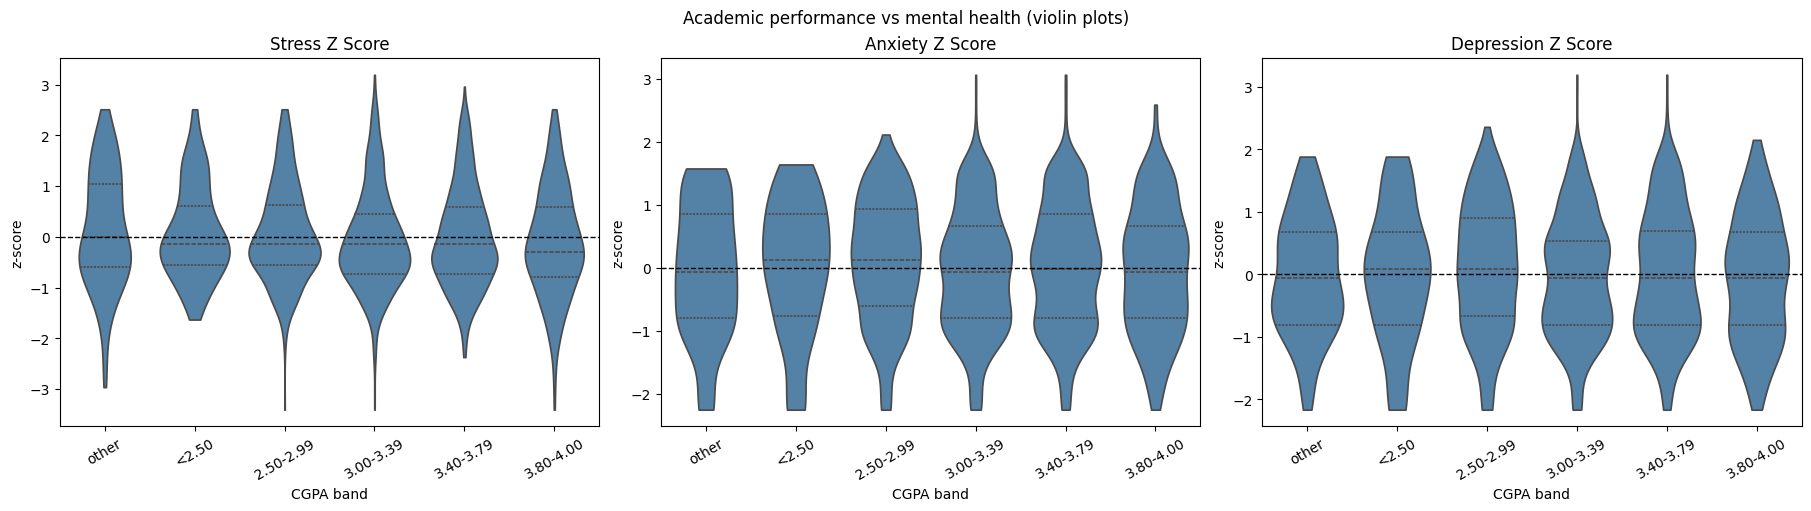

In [128]:
cgpa_summary = (
    mhp_dataset.groupby("cgpa", observed=True)[Z_SCORE_COLS]
    .agg(["count", "mean", "median"])
    .round(3)
)
print("Mental-health z-score summary by CGPA band:")
display(cgpa_summary)

fig5, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, col in zip(axes, Z_SCORE_COLS):
    sns.violinplot(
        data=mhp_dataset,
        x="cgpa",
        y=col,
        ax=ax,
        color="steelblue",
        inner="quartile",
        cut=0,
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("CGPA band")
    ax.set_ylabel("z-score")
    ax.tick_params(axis="x", rotation=30)

fig5.suptitle("Academic performance vs mental health (violin plots)")
plt.show()

In [129]:
fig5.savefig(PLOTS / "cgpa_vs_mhp_violin.svg", format="svg", bbox_inches="tight")

### timeline of burnout

Mental-health z-score summary by academic year:


stress_z_score               anxiety_z_score                \
                       count   mean median           count   mean median   
academic_year                                                              
unknown                    5  0.156  0.156               4  0.158  0.218   
first                    654 -0.114 -0.296             651 -0.171 -0.245   
second                   430  0.122    0.0             430  0.087  0.119   
third                    684  0.039 -0.148             682  0.105  0.119   
fourth                   459 -0.036 -0.148             458  0.003 -0.063   
other                    147  0.074    0.0             146  0.005 -0.019   

              depression_z_score                
                           count   mean median  
academic_year                                   
unknown                        5  0.111  0.069  
first                        654 -0.139 -0.214  
second                       430   0.09  0.086  
third                        684  0.084  0.086  
fourth                       459 -0.024 -0.064  
other                        147  0.034 -0.139

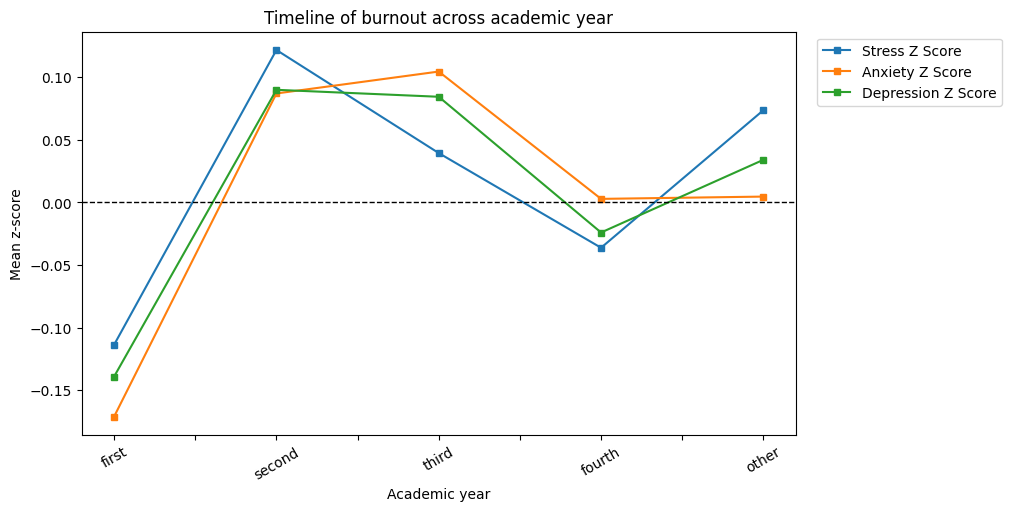

In [130]:
year_summary = (
    mhp_dataset.groupby("academic_year", observed=True)[Z_SCORE_COLS]
    .agg(["count", "mean", "median"])
    .round(3)
)
print("Mental-health z-score summary by academic year:")
display(year_summary)

timeline_data = mhp_dataset[mhp_dataset["academic_year"] != "unknown"].copy()

timeline_mean = timeline_data.groupby("academic_year", observed=True)[
    Z_SCORE_COLS
].mean()
timeline_mean.columns = [col.replace("_", " ").title() for col in timeline_mean.columns]

fig6, ax6 = plt.subplots(figsize=(10, 5), constrained_layout=True)

timeline_mean.plot(kind="line", marker="s", markersize=5, ax=ax6)

ax6.axhline(0, color="black", linestyle="--", linewidth=1)
ax6.set_title("Timeline of burnout across academic year")
ax6.set_xlabel("Academic year")
ax6.set_ylabel("Mean z-score")
ax6.tick_params(axis="x", rotation=30)
ax6.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

In [131]:
fig6.savefig(PLOTS / "mhp_through_years.svg", format="svg", bbox_inches="tight")